![Logo](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/shared_assets/logo.png)

**Developers:** Zoltan Barta  
**Date:** 2026-03-08  
**Version:** 2025-26/2

[<img src="https://colab.research.google.com/assets/colab-badge.svg">](https://colab.research.google.com/github/BartaZoltan/deep-reinforcement-learning-course/blob/main/notebooks/sessions/5_n_step_td_eligibility_traces/n_step_td_eligibility_traces.ipynb)

# Practice 5: n-step Returns and Eligibility Traces

## Summary

In Practice 4, we learned one-step Temporal-Difference methods: **TD(0)** for prediction and **SARSA** / **Q-learning** for control. In this session, we extend that line in the most natural direction: instead of bootstrapping after exactly one step, we allow the update target to look ahead for multiple steps.

This notebook follows one coherent progression:
- **TD(0) -> n-step TD** for prediction,
- **SARSA -> n-step SARSA** for control,
- **lambda-return -> eligibility traces -> SARSA(lambda)**.

The main environment is **CliffWalking**, because it keeps the whole session visually interpretable. At the end, we add **Taxi** as an optional extension environment for extra experiments.


## From One-Step TD to Multi-Step Targets

Recall the two extremes:

Monte Carlo uses the full return

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots
$$

while TD(0) uses the one-step bootstrapped target

$$
R_{t+1} + \gamma V(S_{t+1}).
$$

The **n-step return** sits in between:

$$
G_{t:t+n} = R_{t+1} + \gamma R_{t+2} + \cdots + \gamma^{n-1} R_{t+n} + \gamma^n V(S_{t+n}).
$$

So:
- `n = 1` recovers TD(0),
- large `n` moves us toward Monte Carlo.

This is the main idea of the session: we do not have to choose only between "bootstrap immediately" and "wait until the end of the episode". We can choose an intermediate horizon.

Why this matters:
- **short backups** usually update faster and use less future data, but depend more heavily on the current estimate,
- **long backups** use more real rewards, so they propagate outcome information farther, but they also wait longer and may be noisier,
- the choice of `n` changes how quickly credit travels backward through a trajectory.

It is helpful to read the n-step target in two parts:
- the first `n` rewards are **real experience**,
- the final term is a **bootstrap estimate** of what happens after that horizon.

That interpretation will stay the same throughout the notebook:
- in prediction we will bootstrap from `V`,
- in control we will bootstrap from `Q`,
- and with eligibility traces we will effectively mix many such backup depths at once.

So the session is not really about one new formula. It is about a new way of thinking about **credit assignment over time**.

### Visual Connection: From One-Step TD to Monte Carlo

![From one-step TD to Monte Carlo](assets/1_step_to_montecarlo.png)

This figure is a useful way to read the whole session at a glance.

- Moving from left to right means increasing the **backup depth**.
- The short-horizon end uses more bootstrapping and less real future reward.
- The long-horizon end uses more real reward and less dependence on the current estimate.

The important endpoint is the right-hand side:
- in an **episodic** problem, if the backup horizon keeps growing until the episode ends, there is no future bootstrap term left,
- the target becomes the full sampled return,
- so `TD(∞)` is effectively **Monte Carlo**.

That is exactly the connection we use in this notebook:
- small `n` behaves like one-step TD,
- large `n` moves toward Monte Carlo,
- and eligibility traces can be understood as combining many such backup depths rather than choosing only one.

One notation detail is worth keeping in mind:
- this picture labels methods by **backup length** (`TD(1)`, `TD(2)`, ...),
- while Sutton & Barto often write one-step state-value TD as **TD(0)**,
- so here the main conceptual point is the horizon length, not the `lambda` notation.

In [ ]:
!wget https://github.com/BartaZoltan/deep-reinforcement-learning-course/raw/main/notebooks/sessions/5_n_step_td_eligibility_traces/utils.py

In [ ]:
from __future__ import annotations

from pathlib import Path
import importlib.util


import numpy as np
from IPython.display import Image, display

try:
    import gymnasium as gym
except Exception:
    gym = None

def _load_session5_utils():
    candidates = [
        Path('utils.py'),
        Path('notebooks/sessions/5_n_step_td_eligibility_traces/utils.py'),
        Path('/content/notebooks/sessions/5_n_step_td_eligibility_traces/utils.py'),
    ]

    utils_path = next((p for p in candidates if p.exists()), None)
    if utils_path is None:
        raise FileNotFoundError('Session 5 utils.py not found.')

    spec = importlib.util.spec_from_file_location('session5_utils', utils_path)
    module = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(module)
    return module


s5u = _load_session5_utils()
SEED = 42
s5u.set_seed(SEED)


NameError: name 'repo_path' is not defined

## Session Setup

**Why CliffWalking for the main notebook?**

Because it highlights exactly what we care about here:
- delayed credit assignment,
- propagation speed of reward information,
- visible policy differences under different backup depths.

For prediction, we will evaluate a fixed hand-crafted policy. For control, we will let the agent learn with **n-step SARSA** and **SARSA(lambda)**.


CliffWalking: nS = 48 | nA = 4
Taxi:         nS = 500 | nA = 6


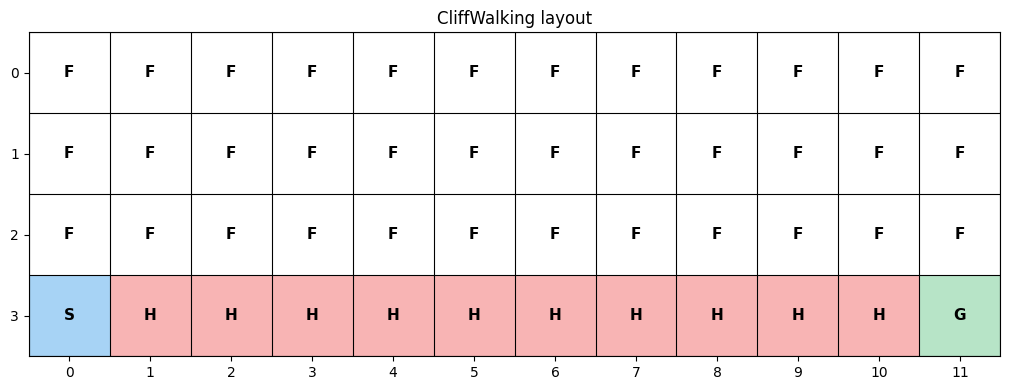

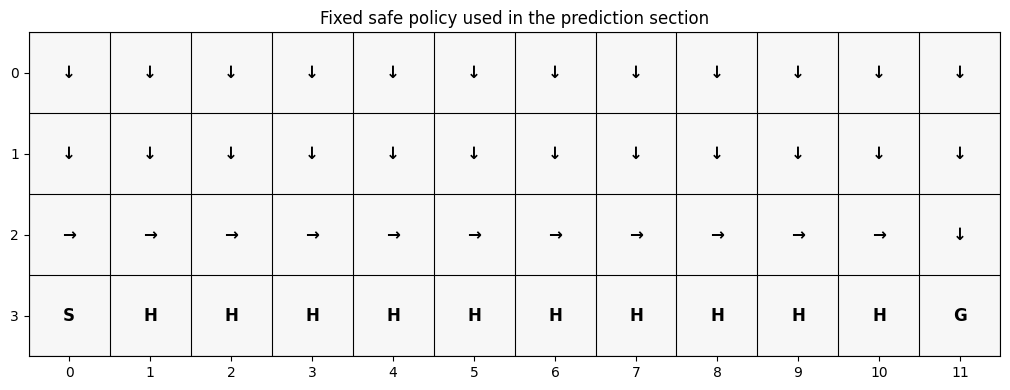

In [ ]:
if gym is None:
    raise RuntimeError('Gymnasium is required for this notebook block. Please install gymnasium.')

ASSET_ROOT = Path('notebooks/sessions/5_n_step_td_eligibility_traces/assets/cell_outputs')
if not ASSET_ROOT.parent.parent.exists():
    ASSET_ROOT = Path('assets/cell_outputs')
ASSET_ROOT.mkdir(parents=True, exist_ok=True)

env_cliff = gym.make('CliffWalking-v1')
env_taxi = gym.make('Taxi-v3')

VALID_CLIFF_START_STATES = s5u.valid_cliff_start_states(env_cliff.observation_space.n)
SAFE_POLICY_ACTIONS = np.array([s5u.safe_cliff_policy(s) for s in range(env_cliff.observation_space.n)], dtype=int)

print('CliffWalking: nS =', env_cliff.observation_space.n, '| nA =', env_cliff.action_space.n)
print('Taxi:         nS =', env_taxi.observation_space.n, '| nA =', env_taxi.action_space.n)

s5u.plot_cliffwalking_map(title='CliffWalking layout')
s5u.plot_cliffwalking_policy(SAFE_POLICY_ACTIONS, title='Fixed safe policy used in the prediction section')
# s5u.plot_epsilon_greedy_action_probs(
#     epsilon=0.10,
#     greedy_action=1,
#     title='Illustration: epsilon-greedy action probabilities at one state',
# )


The three setup visuals fix the intuition for the rest of the notebook.

- The **CliffWalking layout** marks the start, the goal, and the dangerous cliff cells. This is the environment where delayed credit assignment will be most visible.
- The **fixed safe policy** shows the hand-crafted policy used in the prediction task. It deliberately takes the long safe path, so the value function should reflect a conservative but reliable route to the goal.
<!-- - The **epsilon-greedy probability plot** reminds us what the control algorithms optimize under exploration: one action has the highest probability, but every action still has a small chance of being sampled. -->

At this point the main expectation is simple: prediction will evaluate a known policy on this grid, while control will learn a policy and we will compare how fast information propagates under different backup rules.


## Warm-up: Manual n-step Return Calculation

Before implementing algorithms, compute a few multi-step targets by hand.

Suppose the agent follows a short CliffWalking fragment with rewards

$$
R_{t+1} = R_{t+2} = R_{t+3} = -1
$$

and after those rewards we bootstrap from an estimated future value.

This is the mechanical meaning of an n-step target: **real rewards first, one bootstrap term at the horizon**.


In [3]:
rewards_example = [-1.0, -1.0, -1.0, -1.0, -1.0]
bootstrap_value = -4.0
gamma = 1.0


def manual_n_step_return(rewards: list[float], gamma: float, bootstrap_value: float) -> float:
    total = 0.0
    for k, reward in enumerate(rewards):
        total += (gamma ** k) * float(reward)
    total += (gamma ** len(rewards)) * float(bootstrap_value)
    return float(total)


for n in [1, 3, 5]:
    G = manual_n_step_return(rewards_example[:n], gamma=gamma, bootstrap_value=bootstrap_value)
    print(f'{n}-step target = {G:.1f}')

print('\nInterpretation: as n increases, more of the target comes from real rewards and less from bootstrapping.')


1-step target = -5.0
3-step target = -7.0
5-step target = -9.0

Interpretation: as n increases, more of the target comes from real rewards and less from bootstrapping.


## Task 1: Implement the n-step Return Helper

**Goal.** Write a reusable helper that computes an n-step target from:
- a list of rewards collected after time step `t`,
- a discount factor `gamma`,
- and one endpoint bootstrap value.

The helper should implement the pattern
- `reward[0]` is the immediate reward `R_{t+1}`,
- `reward[1]` is `R_{t+2}`,
- and the bootstrap value is added only after all observed rewards have been discounted.

So the returned target is conceptually
- `G = reward[0] + gamma * reward[1] + ... + gamma^n * bootstrap_value`,
- where `n = len(rewards)`.

**Implementation checklist:**
- start from `total = 0.0`,
- loop through the reward list with its index,
- add each discounted reward contribution,
- add the final bootstrap term with exponent `len(rewards)`,
- return a Python `float`.

**Common mistakes to avoid:**
- discounting the first reward by `gamma` instead of by `1`,
- using the wrong exponent for the bootstrap term,
- forgetting that this function does not interact with the environment at all.

**Coding region.** The next code cell contains the marked block to complete. The sanity checks under the function should pass unchanged.

In [4]:
def compute_n_step_return(
    rewards: list[float],
    gamma: float,
    bootstrap_value: float = 0.0,
) -> float:
    """Compute an n-step return from rewards and an endpoint bootstrap estimate."""
    
    ########################################################################
    total = 0.0
    for k, reward in enumerate(rewards):
        total += (float(gamma) ** k) * float(reward)
    total += (float(gamma) ** len(rewards)) * float(bootstrap_value)
    ########################################################################
    return float(total)


assert np.isclose(compute_n_step_return([-1.0], gamma=1.0, bootstrap_value=-7.0), -8.0)
assert np.isclose(compute_n_step_return([-1.0, -1.0, -1.0], gamma=1.0, bootstrap_value=-4.0), -7.0)
assert np.isclose(compute_n_step_return([1.0, 2.0], gamma=0.5, bootstrap_value=4.0), 1.0 + 0.5 * 2.0 + 0.25 * 4.0)

print('Task 1 helper passed basic sanity checks.')

Task 1 helper passed basic sanity checks.


## n-step TD Prediction

We now move from isolated trajectory fragments to repeated learning updates.

For prediction, the goal is fixed:
- the policy is given,
- the environment is sampled repeatedly,
- and we want to estimate the value function of that policy.

Compared with TD(0), one implementation detail changes immediately:
- the update for time `t` is no longer available after a single step,
- we must wait until we have seen enough future rewards,
- so we need a short rolling buffer of states and rewards.

That delayed update is the key implementation idea behind n-step methods.

A useful way to think about one episode is this:
- at time `t`, we may still be collecting information,
- at the same time, we may already have enough information to update an earlier state `S_tau`,
- so sampling and updating are slightly out of sync.

This is why the algorithm keeps both:
- a running time index `t`,
- and an update index `tau = t - n + 1`.

Once `tau >= 0`, the update for `S_tau` becomes available.

There are two cases when building the target:
- if the episode is still alive far enough into the future, we sum `n` rewards and then bootstrap,
- if the episode terminates earlier, we use only the rewards that actually happened and drop the bootstrap term.

So n-step TD prediction is still a TD method, but it is less myopic than TD(0): it waits longer before updating and therefore uses a longer slice of real experience.

To make the state-value heatmaps more informative, the prediction experiment uses **exploring starts** on CliffWalking: the episode still follows the same fixed policy, but we sometimes start from different non-terminal states so more of the grid gets visited. That makes it easier to see how value information spreads across the state space instead of only near the default start state.

## Reference: Monte Carlo Baseline

This helper is provided as a reference implementation.

Its purpose is to give us a longer-horizon baseline before moving to bootstrapped multi-step updates.


In [5]:
def mc_state_value_prediction(
    env,
    policy_fn,
    *,
    n_episodes: int,
    gamma: float,
    max_steps: int = 200,
    exploring_starts: bool = False,
    seed: int = SEED,
):
    rng = np.random.default_rng(seed)
    nS = env.observation_space.n
    V = np.zeros(nS, dtype=float)
    returns_sum = np.zeros(nS, dtype=float)
    returns_count = np.zeros(nS, dtype=float)

    # Reference implementation: first-visit Monte Carlo prediction under the fixed policy.
    for _ in range(n_episodes):
        states, rewards = s5u.generate_policy_episode(
            env,
            policy_fn,
            rng=rng,
            max_steps=max_steps,
            exploring_starts=exploring_starts,
            valid_start_states=VALID_CLIFF_START_STATES,
        )

        first_visit_index = {}
        for t, state in enumerate(states[:-1]):
            if state not in first_visit_index:
                first_visit_index[state] = t

        G = 0.0
        for t in reversed(range(len(states) - 1)):
            G = float(rewards[t + 1]) + float(gamma) * G
            state = int(states[t])
            if first_visit_index[state] != t:
                continue
            returns_sum[state] += G
            returns_count[state] += 1.0
            V[state] = returns_sum[state] / returns_count[state]

    return V

## Task 2: Implement n-step TD Prediction

**Goal.** Implement tabular **n-step TD prediction** for a fixed policy on CliffWalking.

The function should return:
- the learned state-value vector `V`,
- and a history of the estimated start-state value after each episode.

**Buffer convention used in this notebook:**
- `states[0] = S_0`,
- `rewards[0] = 0.0` is just a placeholder,
- after stepping from `states[t]`, store the transition reward in `rewards[t+1]` and the next state in `states[t+1]`.

**Per-episode structure:**
1. Reset the environment and initialize `states`, `rewards`, `T`, and `t`.
2. If `t < T`, follow the fixed policy, step once, and append the new state and reward.
3. Compute `tau = t - n + 1`. Only when `tau >= 0` do we have enough information to update `S_tau`.
4. Build the n-step target by summing rewards from `tau+1` up to `min(tau+n, T)`.
5. If `tau + n < T`, add the bootstrap term `gamma^n * V[S_{tau+n}]`.
6. Apply the TD update to `V[S_tau]`.
7. Stop when `tau == T - 1`, because that means the final pending update has been processed.

**What to pay attention to:**
- the update is delayed, so `t` and `tau` are not the same index,
- terminal episodes may end before `n` rewards are available,
- once the episode has terminated, there is no bootstrap term,
- append the start-state estimate only once per episode, after the episode loop finishes.

**Coding region.** The next code cell marks the full training loop to implement.

In [ ]:
def n_step_td_prediction(
    env,
    policy_fn,
    n: int,
    alpha: float,
    gamma: float,
    n_episodes: int,
    max_steps: int = 200,
    exploring_starts: bool = False,
    seed: int = SEED,
):
    """Tabular n-step TD prediction under a fixed policy."""
    rng = np.random.default_rng(seed)
    V = np.zeros(env.observation_space.n, dtype=float)
    start_state_history = []

    ########################################################################
    for _ in range(n_episodes):
        if exploring_starts and env.spec is not None and env.spec.id == 'CliffWalking-v1':
            state = s5u.reset_cliff_with_exploring_start(env, rng, VALID_CLIFF_START_STATES)
        else:
            state, _ = env.reset(seed=int(rng.integers(0, 10_000_000)))
            state = int(state)

        states = [int(state)]
        rewards = [0.0]
        T = np.inf
        t = 0

        while True:
            if t < T:
                action = int(policy_fn(states[t]))
                next_state, reward, terminated, truncated, _ = env.step(action)
                states.append(int(next_state))
                rewards.append(float(reward))
                if terminated or truncated:
                    T = t + 1

            tau = t - n + 1
            if tau >= 0:
                G = 0.0
                upper = tau + n if np.isinf(T) else min(tau + n, int(T))
                for i in range(tau + 1, upper + 1):
                    G += (float(gamma) ** (i - tau - 1)) * float(rewards[i])
                if tau + n < T:
                    G += (float(gamma) ** n) * float(V[states[tau + n]])
                s_tau = int(states[tau])
                V[s_tau] += float(alpha) * (G - V[s_tau])

            if tau == T - 1:
                break

            t += 1

    ########################################################################
        start_state_history.append(float(V[s5u.START_STATE]))

    return V, np.asarray(start_state_history, dtype=float)

### Prediction Experiment: TD(0) vs n-step TD on CliffWalking

We use two complementary views:
- **standard starts** for the start-state learning curve,
- **exploring starts** for early-stage heatmaps over the whole grid.

The heatmaps below are intentionally taken after a limited training budget so the effect of backup depth is still visible. A Monte Carlo estimate of the same fixed policy acts as the reference value function.

Monte Carlo reference for the CliffWalking start state: -13.0
Using 150 exploring-start episodes for the value maps.
Mean absolute error vs MC: {'n=1': 2.565, 'n=3': 1.636, 'n=5': 1.538}


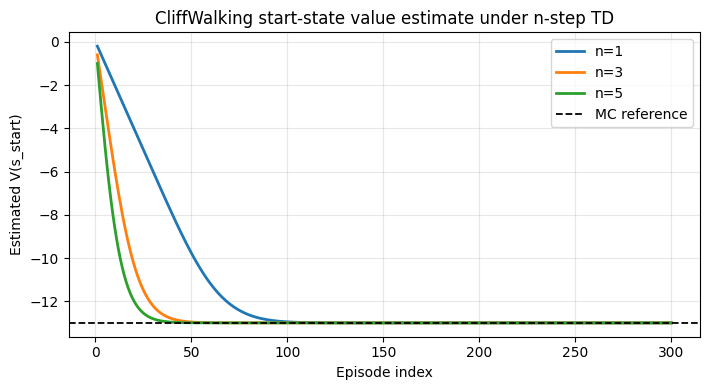

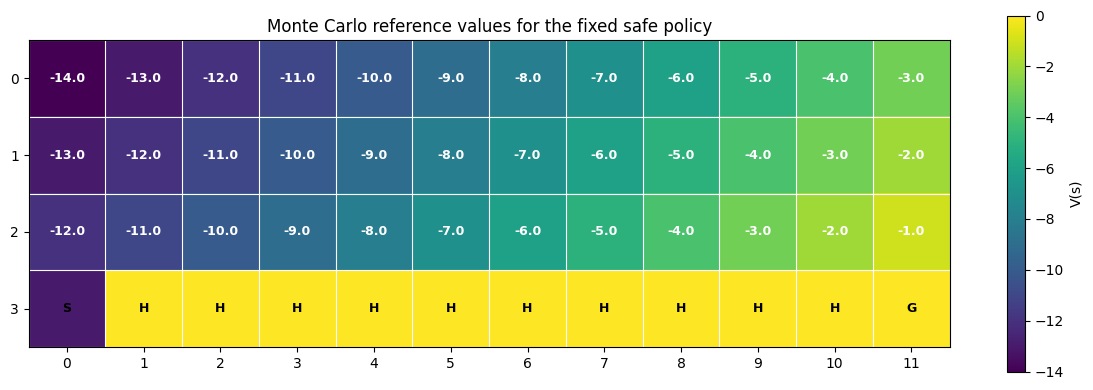

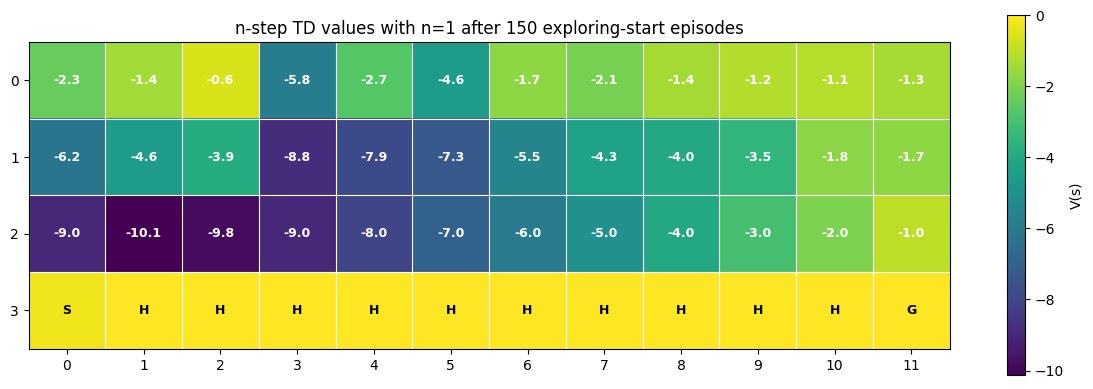

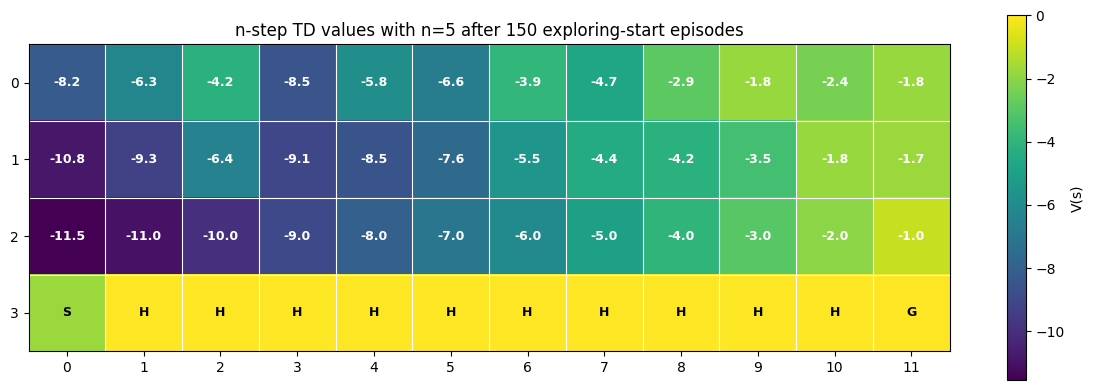

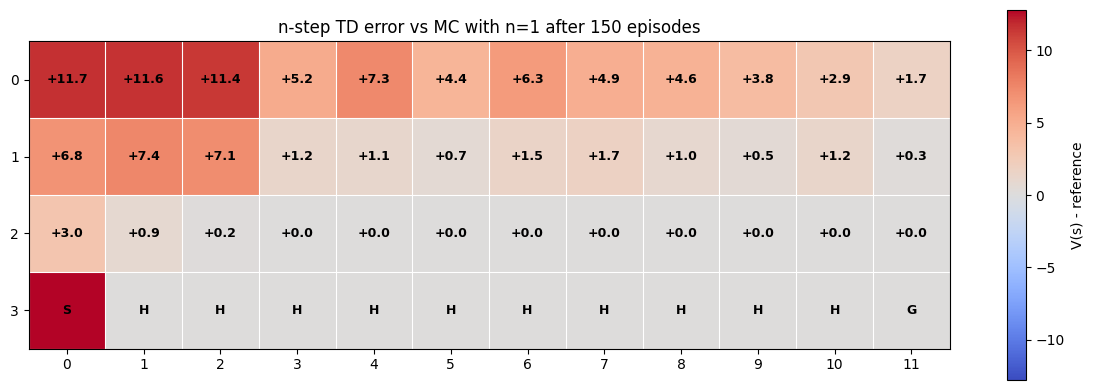

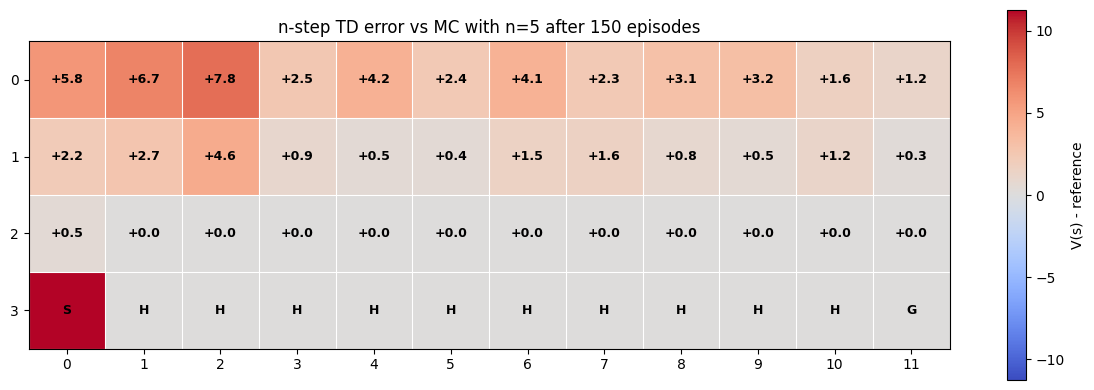

In [7]:
gamma = 1.0
heatmap_episodes = 150

v_mc_ref = mc_state_value_prediction(
    env_cliff,
    s5u.safe_cliff_policy,
    n_episodes=4000,
    gamma=gamma,
    max_steps=50,
    exploring_starts=True,
    seed=SEED,
)

prediction_histories = {}
prediction_values = {}
prediction_mae = {}

for n in [1, 3, 5]:
    V_standard, hist = n_step_td_prediction(
        env_cliff,
        s5u.safe_cliff_policy,
        n=n,
        alpha=0.20,
        gamma=gamma,
        n_episodes=300,
        max_steps=50,
        exploring_starts=False,
        seed=SEED,
    )
    del V_standard
    prediction_histories[f'n={n}'] = hist

    V_explore, _ = n_step_td_prediction(
        env_cliff,
        s5u.safe_cliff_policy,
        n=n,
        alpha=0.20,
        gamma=gamma,
        n_episodes=heatmap_episodes,
        max_steps=50,
        exploring_starts=True,
        seed=SEED,
    )
    prediction_values[n] = V_explore
    prediction_mae[f'n={n}'] = float(np.mean(np.abs(V_explore - v_mc_ref)))

mc_start_reference = float(v_mc_ref[s5u.START_STATE])
print('Monte Carlo reference for the CliffWalking start state:', round(mc_start_reference, 3))
print(f'Using {heatmap_episodes} exploring-start episodes for the value maps.')
print('Mean absolute error vs MC:', {k: round(v, 3) for k, v in prediction_mae.items()})

s5u.plot_many_curves(
    prediction_histories,
    title='CliffWalking start-state value estimate under n-step TD',
    ylabel='Estimated V(s_start)',
    hline=mc_start_reference,
    hline_label='MC reference',
)

s5u.plot_cliffwalking_values(v_mc_ref, title='Monte Carlo reference values for the fixed safe policy')
s5u.plot_cliffwalking_values(
    prediction_values[1],
    title=f'n-step TD values with n=1 after {heatmap_episodes} exploring-start episodes',
)
s5u.plot_cliffwalking_values(
    prediction_values[5],
    title=f'n-step TD values with n=5 after {heatmap_episodes} exploring-start episodes',
)

s5u.plot_cliffwalking_value_difference(
    prediction_values[1],
    v_mc_ref,
    title=f'n-step TD error vs MC with n=1 after {heatmap_episodes} episodes',
)
s5u.plot_cliffwalking_value_difference(
    prediction_values[5],
    v_mc_ref,
    title=f'n-step TD error vs MC with n=5 after {heatmap_episodes} episodes',
)

These figures should be read together rather than separately.

- The **start-state value curve** still shows convergence from the usual CliffWalking start state.
- The **Monte Carlo heatmap** is the reference picture for the fixed safe policy.
- The **`n=1` and `n=5` value maps** are now early snapshots, not fully converged solutions. That makes the propagation speed of reward information visible.
- The **error heatmaps** show the signed difference from Monte Carlo, so underestimation and overestimation patterns are easy to spot.

In this environment the final value functions should eventually look very similar, because all methods evaluate the same deterministic policy. The interesting difference is how quickly that structure appears.

The main interpretation is:
- `n=1` updates immediately but moves information backward more locally,
- larger `n` spreads useful value information across several steps sooner,
- with enough data the maps become similar, so the real comparison here is **learning speed** and **error pattern**, not a different final solution.

## From Prediction to Control: n-step SARSA

The next step is to move from value estimation to control.

In prediction, the policy was fixed and we only updated `V`.
In control, the agent must:
- estimate action values `Q(s, a)`,
- behave according to those values,
- and gradually improve the policy at the same time.

The cleanest extension of one-step SARSA is **n-step SARSA**.
Its target becomes

$$
G_{t:t+n} = R_{t+1} + \gamma R_{t+2} + \cdots + \gamma^{n-1} R_{t+n} + \gamma^n Q(S_{t+n}, A_{t+n}).
$$

The structure is almost the same as for n-step TD prediction:
- store a short trajectory segment,
- wait until enough future information is available,
- update an earlier time step with a delayed target.

The important difference is what appears in the bootstrap term.
We no longer bootstrap from a state value `V(S_{t+n})`, but from the value of the **actual next state-action pair** selected by the current policy.

That is why the method is still **on-policy**:
- actions come from the same epsilon-greedy policy we are improving,
- the bootstrap action is the action that this policy actually chose,
- and the update therefore evaluates the same behavior that generated the data.

This is also the conceptual difference from Q-learning:
- SARSA asks "what value does the policy actually follow next?",
- Q-learning asks "what value would the greedy action have next?"

In CliffWalking, that difference is visible in behavior.
Because SARSA learns from the consequences of exploratory moves, it often prefers safer routes near the cliff. n-step SARSA keeps that same on-policy character, but changes how far the reward signal can travel backward in one update.

In [8]:
def epsilon_greedy_action(Q: np.ndarray, state: int, epsilon: float, rng: np.random.Generator) -> int:
    if float(rng.random()) < float(epsilon):
        return int(rng.integers(0, Q.shape[1]))

    q_row = Q[int(state)]
    best_value = np.max(q_row)
    best_actions = np.flatnonzero(q_row == best_value)
    return int(rng.choice(best_actions))





## Task 3: Implement n-step SARSA on CliffWalking

**Goal.** Extend the previous prediction idea to **on-policy control** with a tabular action-value function `Q`.

The function should return a dictionary with:
- the learned table `Q`,
- the final greedy policy derived from `Q`,
- per-episode returns,
- and the number of cliff falls per episode.

**Buffer convention here:**
- `states[t]` stores `S_t`,
- `actions[t]` stores the action actually taken from `S_t`,
- `rewards[t+1]` stores the reward observed after taking `actions[t]`,
- `rewards[0] = 0.0` is again just a placeholder for alignment.

**Per-episode structure:**
1. Reset the environment and choose the first epsilon-greedy action.
2. Store the initial state and action in the buffers.
3. While `t < T`, step using `actions[t]`, append the reward and next state, and accumulate episode statistics.
4. If the episode continues, choose the next epsilon-greedy action and append it to the action buffer.
5. Compute `tau = t - n + 1`.
6. When `tau >= 0`, build the delayed n-step return.
7. If `tau + n < T`, bootstrap with `Q[S_{tau+n}, A_{tau+n}]`.
8. Update only the pair `(S_tau, A_tau)`.
9. Finish when `tau == T - 1`, then store return and cliff-fall counts.

**Important details:**
- this is **SARSA**, so the bootstrap action must be the action actually selected by the current epsilon-greedy policy,
- do not replace the on-policy bootstrap with a `max` over actions,
- count a cliff fall whenever the received reward is `<= -100`,
- the metrics are logged once per episode, not once per step.

**Coding region.** The next code cell contains the marked n-step SARSA training block.

In [9]:
def n_step_sarsa(
    env,
    n: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    n_episodes: int,
    max_steps: int = 500,
    seed: int = SEED,
):
    """On-policy tabular n-step SARSA."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n), dtype=float)
    episode_returns = []
    cliff_falls = []

    ########################################################################
    for _ in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(0, 10_000_000)))
        state = int(state)
        action = epsilon_greedy_action(Q, state, epsilon, rng)

        states = [state]
        actions = [action]
        rewards = [0.0]

        T = np.inf
        t = 0
        episode_return = 0.0
        episode_cliff_falls = 0.0

        while True:
            if t < T:
                next_state, reward, terminated, truncated, _ = env.step(actions[t])
                next_state = int(next_state)
                rewards.append(float(reward))
                states.append(next_state)

                episode_return += float(reward)
                if float(reward) <= -100.0:
                    episode_cliff_falls += 1.0

                if terminated or truncated:
                    T = t + 1
                else:
                    next_action = epsilon_greedy_action(Q, next_state, epsilon, rng)
                    actions.append(next_action)

            tau = t - n + 1
            if tau >= 0:
                G = 0.0
                upper = tau + n if np.isinf(T) else min(tau + n, int(T))
                for i in range(tau + 1, upper + 1):
                    G += (float(gamma) ** (i - tau - 1)) * float(rewards[i])
                if tau + n < T:
                    G += (float(gamma) ** n) * float(Q[states[tau + n], actions[tau + n]])

                s_tau = int(states[tau])
                a_tau = int(actions[tau])
                Q[s_tau, a_tau] += float(alpha) * (G - Q[s_tau, a_tau])

            if tau == T - 1:
                break

            t += 1

    ########################################################################
        episode_returns.append(float(episode_return))
        cliff_falls.append(float(episode_cliff_falls))

    greedy_policy = s5u.greedy_policy_from_q(Q)
    return {
        'Q': Q,
        'greedy_policy': greedy_policy,
        'episode_returns': np.asarray(episode_returns, dtype=float),
        'cliff_falls': np.asarray(cliff_falls, dtype=float),
    }

### Control Experiment: SARSA with Different Backup Depths

We compare three versions of the same control method:
- `n=1` which is ordinary SARSA,
- `n=3`,
- `n=5`.

We look at:
- running mean episodic return,
- greedy policy after training,
- mean greedy return after training,
- number of cliff falls during training.


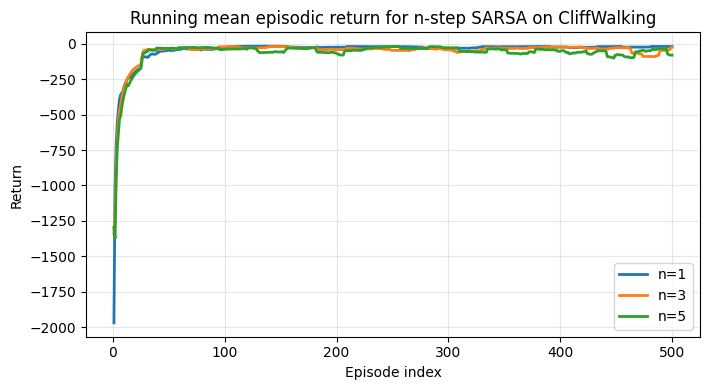

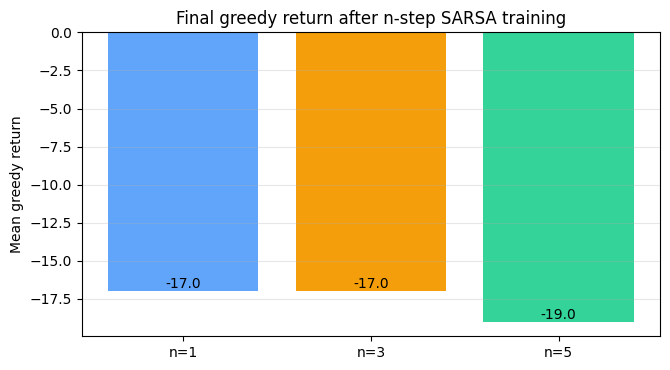

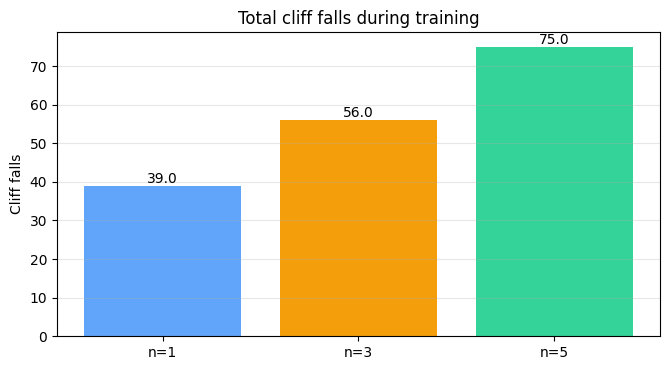

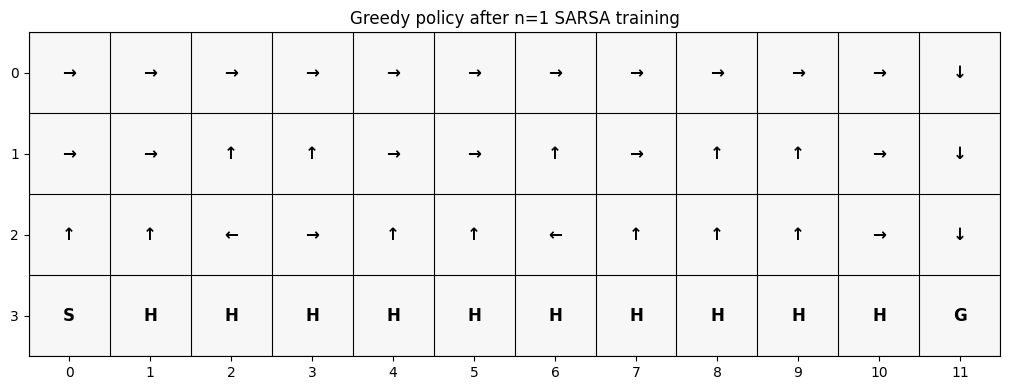

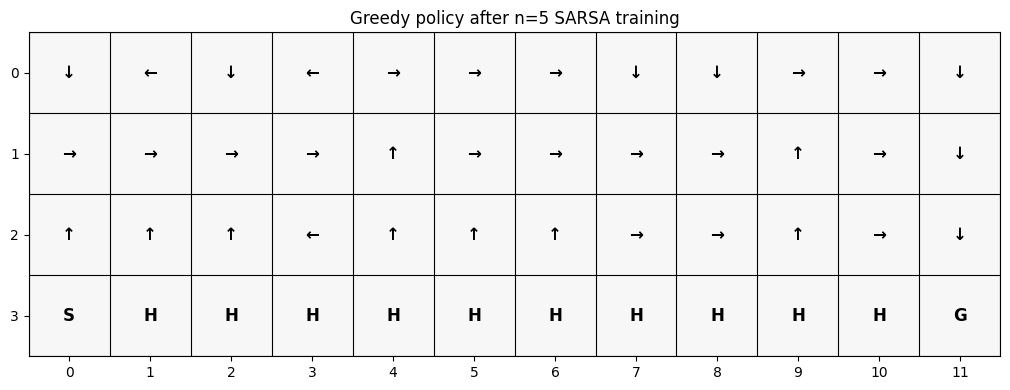

n=1: last-50 training return = -21.18, greedy eval = -17.00 +/- 0.00
n=3: last-50 training return = -56.82, greedy eval = -17.00 +/- 0.00
n=5: last-50 training return = -63.26, greedy eval = -19.00 +/- 0.00


In [10]:
sarsa_n_results = {}
for n in [1, 3, 5]:
    sarsa_n_results[n] = n_step_sarsa(
        env_cliff,
        n=n,
        alpha=0.45,
        gamma=1.0,
        epsilon=0.10,
        n_episodes=500,
        max_steps=200,
        seed=SEED,
    )

control_curves = {
    f'n={n}': s5u.running_mean(result['episode_returns'], window=25)
    for n, result in sarsa_n_results.items()
}
s5u.plot_many_curves(
    control_curves,
    title='Running mean episodic return for n-step SARSA on CliffWalking',
    ylabel='Return',
)

eval_scores = {}
fall_scores = {}
for n, result in sarsa_n_results.items():
    eval_scores[f'n={n}'] = s5u.evaluate_greedy_return(env_cliff, result['greedy_policy'])['mean_return']
    fall_scores[f'n={n}'] = float(np.sum(result['cliff_falls']))

s5u.plot_metric_bars(eval_scores, title='Final greedy return after n-step SARSA training', ylabel='Mean greedy return')
s5u.plot_metric_bars(fall_scores, title='Total cliff falls during training', ylabel='Cliff falls')

s5u.plot_cliffwalking_policy(sarsa_n_results[1]['greedy_policy'], title='Greedy policy after n=1 SARSA training')
s5u.plot_cliffwalking_policy(sarsa_n_results[5]['greedy_policy'], title='Greedy policy after n=5 SARSA training')

for n in [1, 3, 5]:
    last_mean = s5u.summarize_last(sarsa_n_results[n]['episode_returns'], window=50)
    greedy_eval = s5u.evaluate_greedy_return(env_cliff, sarsa_n_results[n]['greedy_policy'])
    print(
        f'n={n}: last-50 training return = {last_mean:.2f}, '
        f'greedy eval = {greedy_eval["mean_return"]:.2f} +/- {greedy_eval["std_return"]:.2f}'
    )


This control block now shows the same idea at the policy-learning level.

- The **training-return curves** show how quickly each `n-step SARSA` variant improves under exploration. Larger `n` often changes the early learning dynamics the most.
- The **final greedy-return bars** summarize what policy quality remains after training noise is removed.
- The **cliff-fall bars** make the risk profile explicit: some settings may learn faster but fall into the cliff more often during exploration.
- The **policy plots** reveal the behavioral difference directly. A safer policy stays away from the cliff, while a more aggressive one hugs the edge to shorten the path.

What matters here is the tradeoff between speed, safety during learning, and the final route induced by the learned action values.


### GIF Visualization: n-step SARSA Policies

The aggregate curves are useful, but one greedy rollout often makes the learned behavior much easier to read.

The GIFs below replay one CliffWalking episode for:
- `n=1`, which is ordinary SARSA,
- `n=5`, which uses a deeper backup horizon.


In [2]:
gif_n1 = s5u.export_cliffwalking_policy_rollout_gif(
    sarsa_n_results[1]['greedy_policy'],
    output_dir=ASSET_ROOT / 'n_step_sarsa_n1',
    reset_seed=SEED,
    gif_name='n_step_sarsa_n1.gif',
    frame_prefix='n1',
    fps=1.5,
)
gif_n5 = s5u.export_cliffwalking_policy_rollout_gif(
    sarsa_n_results[5]['greedy_policy'],
    output_dir=ASSET_ROOT / 'n_step_sarsa_n5',
    reset_seed=SEED,
    gif_name='n_step_sarsa_n5.gif',
    frame_prefix='n5',
    fps=1.5,
)

NameError: name 's5u' is not defined

In [ ]:
from IPython.display import Image, display

print('n=1 rollout return:', gif_n1['total_return'], '| steps:', gif_n1['steps_executed'])
display(Image(filename=gif_n1['gif_path']))
print('\n')
print('n=5 rollout return:', gif_n5['total_return'], '| steps:', gif_n5['steps_executed'])
display(Image(filename=gif_n5['gif_path']))

- Watch **how close the agent moves to the cliff** and whether it takes a short risky route or a slightly longer safer one.
- Compare the **number of steps** and the **total return** printed above. In CliffWalking these two usually move together, unless a fall introduces a large penalty.
- If the paths differ, that is the visible consequence of changing the backup horizon: the algorithms are assigning credit over different effective distances.

This is a useful checkpoint: if two training curves look similar but the rollouts differ, then the policy-level interpretation matters, not just the scalar return.


## Why Eligibility Traces?

So far, we have picked one specific backup depth `n`.

That already gives a useful bridge between TD(0) and Monte Carlo, but it is still restrictive. In practice we often want to combine several horizons at once:
- shorter backups, which are usually lower variance but more biased,
- longer backups, which can propagate information further but are noisier.

The **lambda-return** solves this by combining many n-step returns into one weighted target.
Conceptually:
- small `n` values still contribute,
- larger `n` values also contribute,
- and the parameter `lambda` controls how much weight is given to longer horizons.

This gives a **forward-view** interpretation:
- imagine explicitly constructing many n-step targets,
- weight them geometrically,
- and average them into one return.

That forward view is conceptually clean, but not convenient online, because it refers to many future outcomes at once.

Eligibility traces are the **backward view** of the same idea.
Instead of waiting to build many forward returns explicitly, we keep a decaying trace for recently visited state-action pairs and distribute the current TD error backward through that trace.

The trace answers the question:
- which past states or state-action pairs should still receive credit from what just happened now?

The closer and more recently visited a pair is, the larger its trace tends to be.
So one fresh TD error can update not only the current pair, but also a short history behind it.

This is why eligibility traces are powerful:
- they approximate a whole family of multi-step updates,
- they work naturally online,
- and they often speed up credit assignment without requiring us to choose one single backup depth.

The special cases are worth remembering:
- `lambda = 0` gives the one-step TD/SARSA behavior,
- larger `lambda` keeps credit alive for longer,
- `lambda` close to `1` moves us toward Monte Carlo-like behavior, especially in episodic settings.

## Task 4: Implement Accumulating Traces and SARSA(lambda)

**Goal.** Implement the backward-view version of multi-step credit assignment with **accumulating eligibility traces**.

This function has the same overall outputs as the previous control task:
- learned `Q`,
- final greedy policy,
- episode returns,
- and cliff-fall counts.

**Key idea:** instead of storing an explicit n-step buffer, maintain a trace matrix `E` with the same shape as `Q`.
- `E[s, a]` is larger for recently visited state-action pairs,
- the current TD error is distributed backward through that trace.

**Per-episode structure:**
1. Reset `E` to zeros at the beginning of each episode.
2. Reset the environment and choose the first epsilon-greedy action.
3. Step once in the environment, accumulate return, and count cliff falls.
4. Build the one-step SARSA target:
   - terminal case: `td_target = reward`,
   - non-terminal case: `td_target = reward + gamma * Q[next_state, next_action]`.
5. Compute `delta = td_target - Q[state, action]`.
6. Increase the current trace with `E[state, action] += 1`.
7. Update the full table with `Q += alpha * delta * E`.
8. Decay all traces with `E *= gamma * lambda_`.
9. If the episode is not over, move to `(next_state, next_action)` and continue.

**What to pay attention to:**
- `lambda = 0` should behave like one-step SARSA,
- `E` is reset once per episode, not once per step,
- the table update uses the whole trace matrix at once,
- because this is still on-policy SARSA, the next action must come from the same epsilon-greedy policy.

**Coding region.** In the next code cell, the marked block covers the full trace-based training loop.

In [12]:
def sarsa_lambda(
    env,
    alpha: float,
    gamma: float,
    epsilon: float,
    lambda_: float,
    n_episodes: int,
    max_steps: int = 500,
    seed: int = SEED,
):
    """Tabular SARSA(lambda) with accumulating eligibility traces."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n), dtype=float)
    episode_returns = []
    cliff_falls = []
    
    ########################################################################
    for _ in range(n_episodes):
        E = np.zeros_like(Q)
        state, _ = env.reset(seed=int(rng.integers(0, 10_000_000)))
        state = int(state)
        action = epsilon_greedy_action(Q, state, epsilon, rng)

        episode_return = 0.0
        episode_cliff_falls = 0.0

        for _ in range(max_steps):
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = int(next_state)
            episode_return += float(reward)
            if float(reward) <= -100.0:
                episode_cliff_falls += 1.0

            if terminated or truncated:
                td_target = float(reward)
                next_action = None
            else:
                next_action = epsilon_greedy_action(Q, next_state, epsilon, rng)
                td_target = float(reward) + float(gamma) * float(Q[next_state, next_action])

            delta = td_target - Q[state, action]
            E[state, action] += 1.0
            Q += float(alpha) * delta * E
            E *= float(gamma) * float(lambda_)

            if terminated or truncated:
                break

            state = next_state
            action = int(next_action)

    ########################################################################
        episode_returns.append(float(episode_return))
        cliff_falls.append(float(episode_cliff_falls))

    greedy_policy = s5u.greedy_policy_from_q(Q)
    return {
        'Q': Q,
        'greedy_policy': greedy_policy,
        'episode_returns': np.asarray(episode_returns, dtype=float),
        'cliff_falls': np.asarray(cliff_falls, dtype=float),
    }

### Eligibility Trace Experiment: Varying `lambda`

We now compare:
- `lambda = 0.0` as the one-step SARSA baseline,
- `lambda = 0.5`,
- `lambda = 0.9`.

The goal is not to find one universally best setting. The point is to observe how the trace changes the *style* of learning:
- how quickly value information moves backward,
- how noisy the training curve becomes,
- and whether the final greedy behavior changes in a meaningful way.

A useful mental model is:
- low `lambda` behaves more locally and more like one-step learning,
- high `lambda` keeps more of the recent trajectory active,
- so one TD error influences a longer recent history.

In CliffWalking, the interesting question is whether that longer credit assignment produces:
- faster learning,
- safer policies,
- or just different transient behavior before convergence.

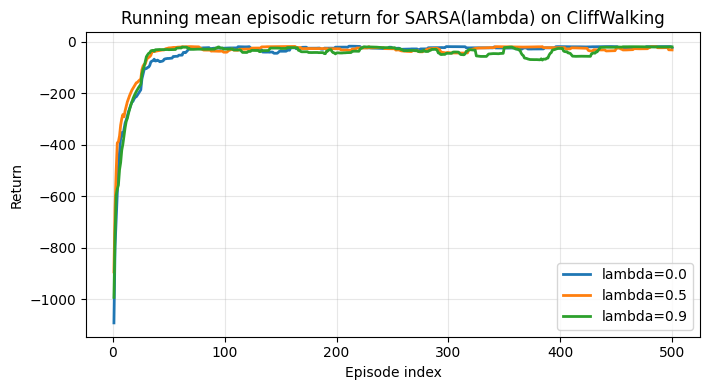

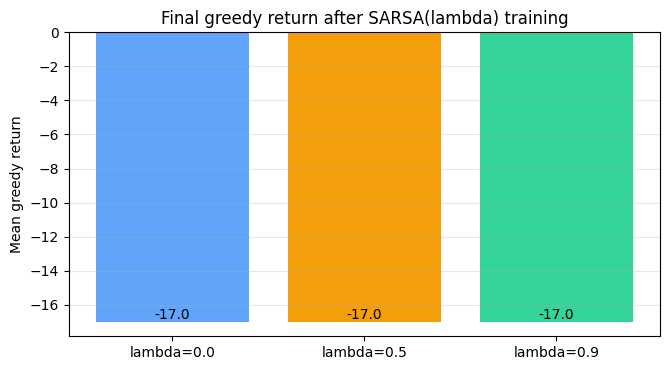

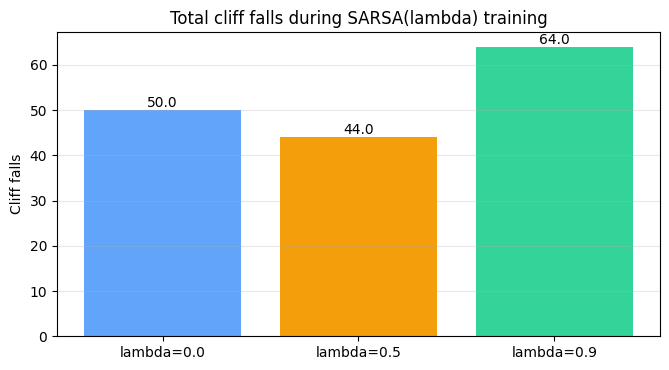

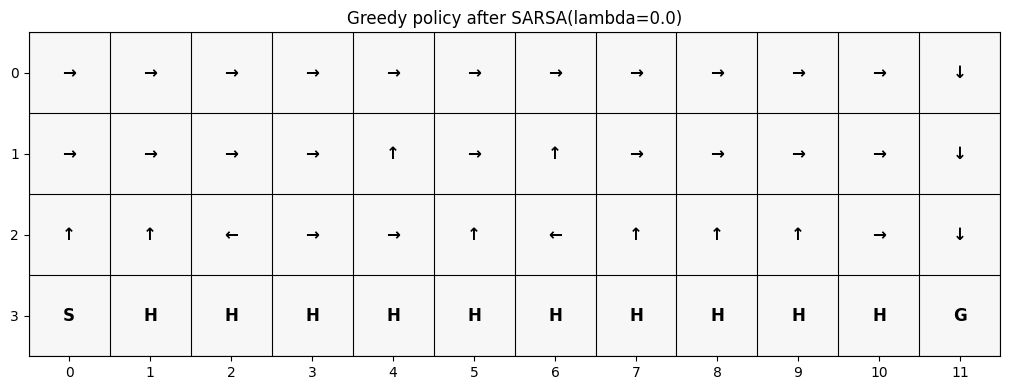

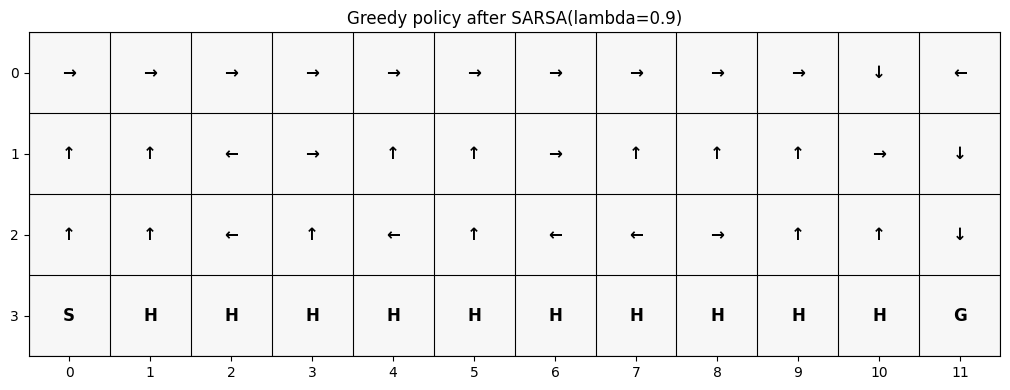

lambda=0.0: last-50 training return = -23.30, greedy eval = -17.00 +/- 0.00
lambda=0.5: last-50 training return = -29.32, greedy eval = -17.00 +/- 0.00
lambda=0.9: last-50 training return = -19.86, greedy eval = -17.00 +/- 0.00


In [13]:
lambda_results = {}
for lambda_ in [0.0, 0.5, 0.9]:
    lambda_results[lambda_] = sarsa_lambda(
        env_cliff,
        alpha=0.35,
        gamma=1.0,
        epsilon=0.10,
        lambda_=lambda_,
        n_episodes=500,
        max_steps=200,
        seed=SEED,
    )

lambda_curves = {
    f'lambda={lambda_}': s5u.running_mean(result['episode_returns'], window=25)
    for lambda_, result in lambda_results.items()
}
s5u.plot_many_curves(
    lambda_curves,
    title='Running mean episodic return for SARSA(lambda) on CliffWalking',
    ylabel='Return',
)

lambda_eval_scores = {}
lambda_fall_scores = {}
for lambda_, result in lambda_results.items():
    label = f'lambda={lambda_}'
    lambda_eval_scores[label] = s5u.evaluate_greedy_return(env_cliff, result['greedy_policy'])['mean_return']
    lambda_fall_scores[label] = float(np.sum(result['cliff_falls']))

s5u.plot_metric_bars(lambda_eval_scores, title='Final greedy return after SARSA(lambda) training', ylabel='Mean greedy return')
s5u.plot_metric_bars(lambda_fall_scores, title='Total cliff falls during SARSA(lambda) training', ylabel='Cliff falls')

s5u.plot_cliffwalking_policy(lambda_results[0.0]['greedy_policy'], title='Greedy policy after SARSA(lambda=0.0)')
s5u.plot_cliffwalking_policy(lambda_results[0.9]['greedy_policy'], title='Greedy policy after SARSA(lambda=0.9)')

for lambda_ in [0.0, 0.5, 0.9]:
    last_mean = s5u.summarize_last(lambda_results[lambda_]['episode_returns'], window=50)
    greedy_eval = s5u.evaluate_greedy_return(env_cliff, lambda_results[lambda_]['greedy_policy'])
    print(
        f'lambda={lambda_}: last-50 training return = {last_mean:.2f}, '
        f'greedy eval = {greedy_eval["mean_return"]:.2f} +/- {greedy_eval["std_return"]:.2f}'
    )


These eligibility-trace plots answer two questions at once: how learning evolves, and what kind of policy is produced at the end.

- The **running-return curves** show whether larger `lambda` helps the agent improve earlier by pushing TD errors farther backward.
- The **greedy-return bars** separate final policy quality from noisy exploratory training episodes.
- The **cliff-fall bars** show whether a setting pays for faster propagation with more dangerous exploratory behavior.
- The **policy heatmaps** reveal whether the learned policy remains cautious or becomes more direct.

Conceptually, this is the same comparison as before, but now `lambda` blends many backup depths instead of fixing one `n` in advance.


### GIF Visualization: SARSA(lambda) Policies

These rollouts give a concrete policy-level view of the effect of eligibility traces.

We compare:
- `lambda=0.0`, which behaves like one-step SARSA,
- `lambda=0.9`, which pushes more credit backward through the trajectory.


In [ ]:
gif_l0 = s5u.export_cliffwalking_policy_rollout_gif(
    lambda_results[0.0]['greedy_policy'],
    output_dir=ASSET_ROOT / 'sarsa_lambda_l0',
    reset_seed=SEED,
    gif_name='sarsa_lambda_l0.gif',
    frame_prefix='l0',
    fps=1.5,
)
gif_l09 = s5u.export_cliffwalking_policy_rollout_gif(
    lambda_results[0.9]['greedy_policy'],
    output_dir=ASSET_ROOT / 'sarsa_lambda_l09',
    reset_seed=SEED,
    gif_name='sarsa_lambda_l09.gif',
    frame_prefix='l09',
    fps=1.5,
)

lambda=0.0 rollout return: -17.0 | steps: 17
lambda=0.9 rollout return: -17.0 | steps: 17


In [ ]:
from IPython.display import Image, display

print('lambda=0.0 rollout return:', gif_l0['total_return'], '| steps:', gif_l0['steps_executed'])
display(Image(filename=gif_l0['gif_path']))
print('\n')
print('lambda=0.9 rollout return:', gif_l09['total_return'], '| steps:', gif_l09['steps_executed'])
display(Image(filename=gif_l09['gif_path']))

These two rollouts are especially useful for connecting the forward and backward views.

- `lambda=0.0` is the one-step baseline, so its GIF is the reference behavior.
- `lambda=0.9` gives more weight to longer-horizon credit assignment, so if the policy changes, that is the behavioral footprint of the trace mechanism.
- If the two GIFs look similar, that is also informative: it means the trace changed learning dynamics more than the final greedy path in this environment.

Compare these GIFs with the earlier `n-step SARSA` rollouts and ask whether `lambda` behaves more like choosing one specific large `n`, or like smoothing over several backup depths at once.


## Optional Extension: Taxi Experiments

`Taxi-v3` is not as visually clean as CliffWalking, but it is a useful extension because:
- episodes are longer,
- delayed consequences matter more,
- sparse and structured rewards make deeper backups interesting.

That changes the teaching value of the environment.
In CliffWalking, the geometry makes policies easy to interpret visually.
In Taxi, the stronger lesson is about *temporal structure*:
- several decisions may need to be correct before reward improves,
- poor actions can have effects many steps later,
- and credit assignment becomes less obvious from a single transition.

So this extension is helpful for testing whether the same algorithms still make sense once the task becomes less immediately visual and more sequentially structured.

We keep the extension compact: one **n-step SARSA** comparison and one **SARSA(lambda)** comparison, both using the same generic implementations from above. The point is not new code, but seeing the same ideas transfer to a second environment with longer horizons.

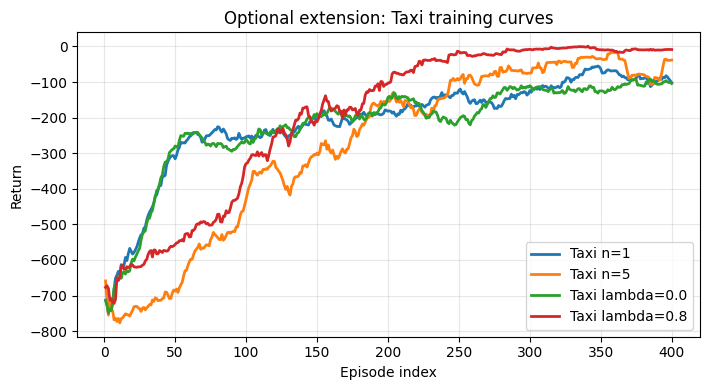

Taxi summary metrics
--------------------
n=1 last-50 mean:       -95.76
n=5 last-50 mean:       -60.28
lambda=0.0 last-50 mean: -99.42
lambda=0.8 last-50 mean: -8.08

Taxi greedy policy evaluation
-----------------------------
n=1 greedy eval:       -232.5
n=5 greedy eval:       -88.77
lambda=0.0 greedy eval: -247.2
lambda=0.8 greedy eval: -159.15


In [15]:
taxi_n1 = n_step_sarsa(
    env_taxi,
    n=1,
    alpha=0.15,
    gamma=0.99,
    epsilon=0.10,
    n_episodes=400,
    max_steps=200,
    seed=SEED,
)
taxi_n5 = n_step_sarsa(
    env_taxi,
    n=5,
    alpha=0.15,
    gamma=0.99,
    epsilon=0.10,
    n_episodes=400,
    max_steps=200,
    seed=SEED,
)
taxi_l0 = sarsa_lambda(
    env_taxi,
    alpha=0.12,
    gamma=0.99,
    epsilon=0.10,
    lambda_=0.0,
    n_episodes=400,
    max_steps=200,
    seed=SEED,
)
taxi_l08 = sarsa_lambda(
    env_taxi,
    alpha=0.12,
    gamma=0.99,
    epsilon=0.10,
    lambda_=0.8,
    n_episodes=400,
    max_steps=200,
    seed=SEED,
)

s5u.plot_many_curves(
    {
        'Taxi n=1': s5u.running_mean(taxi_n1['episode_returns'], window=25),
        'Taxi n=5': s5u.running_mean(taxi_n5['episode_returns'], window=25),
        'Taxi lambda=0.0': s5u.running_mean(taxi_l0['episode_returns'], window=25),
        'Taxi lambda=0.8': s5u.running_mean(taxi_l08['episode_returns'], window=25),
    },
    title='Optional extension: Taxi training curves',
    ylabel='Return',
)

print('Taxi summary metrics')
print('--------------------')
print('n=1 last-50 mean:      ', round(s5u.summarize_last(taxi_n1['episode_returns']), 2))
print('n=5 last-50 mean:      ', round(s5u.summarize_last(taxi_n5['episode_returns']), 2))
print('lambda=0.0 last-50 mean:', round(s5u.summarize_last(taxi_l0['episode_returns']), 2))
print('lambda=0.8 last-50 mean:', round(s5u.summarize_last(taxi_l08['episode_returns']), 2))

print('\nTaxi greedy policy evaluation')
print('-----------------------------')
print('n=1 greedy eval:      ', s5u.evaluate_greedy_return(env_taxi, taxi_n1['greedy_policy'])['mean_return'])
print('n=5 greedy eval:      ', s5u.evaluate_greedy_return(env_taxi, taxi_n5['greedy_policy'])['mean_return'])
print('lambda=0.0 greedy eval:', s5u.evaluate_greedy_return(env_taxi, taxi_l0['greedy_policy'])['mean_return'])
print('lambda=0.8 greedy eval:', s5u.evaluate_greedy_return(env_taxi, taxi_l08['greedy_policy'])['mean_return'])


The Taxi extension should be read as a transfer test of the same ideas in a less transparent environment.

- The **training curves** usually fluctuate more than in CliffWalking, because Taxi has a larger state space and longer trajectories.
- The printed **last-50 means** summarize short-term training quality, while the **greedy evaluation numbers** check whether the learned policy is actually useful when exploration is removed.
- If deeper backups or larger `lambda` help more here than in CliffWalking, that supports the intuition that eligibility traces are particularly valuable when rewards are delayed over longer horizons.

This section is optional because the environment is harder to visualize, but the experiment is useful for showing that the same algorithms can matter differently once the task becomes longer and more structured.
